# Spotify Hit Predictor: Random Forest Model

This second model uses Random Forest as an alternative approach to compare against the XGBoost model.

Key differences from Model 1:
- Used a genre-relative hit threshold (top 30% within each genre) instead of a fixed cutoff of 50
- Used cross-validation instead of a single train/test split
- Added outlier removal using IQR before training

## Loading and Cleaning

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.dummy import DummyClassifier

# Load dataset
df = pd.read_csv("Top_10_genres_Spotify_Music.csv")

# Clean column names
df.columns = df.columns.str.strip()

# Drop missing key features
df = df.dropna(subset=['energy', 'danceability'])

# Drop non-predictive metadata
cols_to_drop = ['track_name', 'artist_name', 'album_name', 'track_id']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

df.head()


,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,is_hit
0,57,120058,1,0.708,0.235,11,-16.156,0,0.3180,0.77200,0.002380,0.1030,0.1690,139.998,4,emo,1
1,4,158391,0,0.869,0.726,11,-5.654,0,0.0459,0.07840,0.000000,0.1070,0.3430,124.023,4,pop,0
2,44,380306,0,0.473,0.858,1,-4.982,0,0.0533,0.00156,0.242000,0.1150,0.0439,124.987,4,grunge,0
3,73,195200,1,0.768,0.374,7,-12.490,1,0.7230,0.28800,0.000002,0.1110,0.3980,75.503,4,chill,1
4,58,264538,0,0.458,0.384,8,-5.045,1,0.0267,0.73400,0.000000,0.0985,0.1570,148.210,3,k-pop,1


## Removing Outliers

In [3]:
def find_outliers_IQR(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    return (series < (q1 - 1.5 * iqr)) | (series > (q3 + 1.5 * iqr))

numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    mask = find_outliers_IQR(df[col])
    df = df[~mask]

## Training Per Genre

In [4]:
genres = df['track_genre'].value_counts().head(10).index

results = []
feature_importances = {}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for genre in genres:
    subset = df[df['track_genre'] == genre].copy()

    # Define genre-specific hit threshold
    threshold = subset['popularity'].quantile(0.7)
    subset['is_hit'] = (subset['popularity'] >= threshold).astype(int)

    # Skip small or invalid datasets
    if len(subset) < 100 or subset['is_hit'].nunique() < 2:
        continue

    # Features and labels
    X = subset.drop(columns=['popularity', 'is_hit', 'track_genre'])
    y = subset['is_hit']

    # Model
    model = RandomForestClassifier(
        n_estimators=250,
        max_depth=10,
        min_samples_leaf=5,
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1
    )

    # Cross-validation metrics
    auc_scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc')
    f1_scores = cross_val_score(model, X, y, cv=cv, scoring='f1')
    precision_scores = cross_val_score(model, X, y, cv=cv, scoring='precision') # Added calculation for precision scores

    # Baseline comparison
    dummy = DummyClassifier(strategy='most_frequent')
    dummy_f1 = cross_val_score(dummy, X, y, cv=cv, scoring='f1').mean()

    results.append({
        'Genre': genre,
        'ROC-AUC': auc_scores.mean(),
        'F1-Score': f1_scores.mean(),
        'Precision': precision_scores.mean(), # Now precision_scores is defined
        'Baseline F1': dummy_f1
    })

    print(f"\nGenre: {genre}")
    print(f"ROC-AUC: {auc_scores.mean():.3f}")
    print(f"F1-Score: {f1_scores.mean():.3f}")
    print(f"Precision: {precision_scores.mean():.3f}") # Now precision_scores is defined
    print(f"Baseline F1: {dummy_f1:.3f}")
    print("-" * 40)

    # Fit once to extract feature importance
    model.fit(X, y)
    fi = pd.DataFrame({
        'Feature': X.columns,
        'Importance': model.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    feature_importances[genre] = fi



Genre: pop-film
ROC-AUC: 0.658
F1-Score: 0.387
Precision: 0.472
Baseline F1: 0.000
----------------------------------------

Genre: k-pop
ROC-AUC: 0.806
F1-Score: 0.613
Precision: 0.554
Baseline F1: 0.000
----------------------------------------

Genre: grunge
ROC-AUC: 0.504
F1-Score: 0.245
Precision: 0.338
Baseline F1: 0.000
----------------------------------------

Genre: sertanejo
ROC-AUC: 0.604
F1-Score: 0.446
Precision: 0.503
Baseline F1: 0.000
----------------------------------------

Genre: indian
ROC-AUC: 0.526
F1-Score: 0.284
Precision: 0.333
Baseline F1: 0.000
----------------------------------------

Genre: anime
ROC-AUC: 0.571
F1-Score: 0.285
Precision: 0.369
Baseline F1: 0.000
----------------------------------------

Genre: pop
ROC-AUC: 0.666
F1-Score: 0.400
Precision: 0.482
Baseline F1: 0.000
----------------------------------------

Genre: chill
ROC-AUC: 0.473
F1-Score: 0.223
Precision: 0.261
Baseline F1: 0.000
----------------------------------------

Genre: emo
ROC-A

## Results

In [5]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='ROC-AUC', ascending=False)

results_df

#Overall Performance
results_df.mean(numeric_only=True)

,0
ROC-AUC,0.601444
F1-Score,0.352399
Precision,0.420208
Baseline F1,0.000000


## Which Features Mattered Most

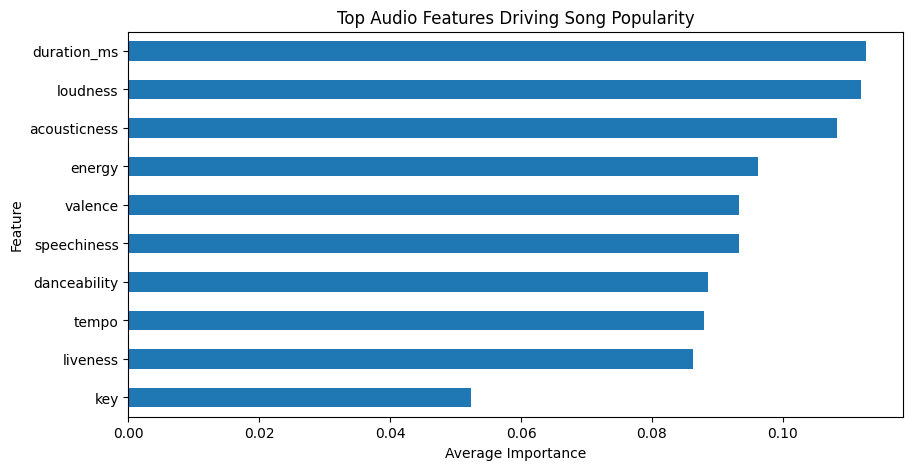

In [6]:
all_importances = pd.concat(feature_importances.values())

global_importance = (
    all_importances
    .groupby('Feature')['Importance']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))
global_importance.head(10).sort_values().plot(kind='barh')
plt.title("Top Audio Features Driving Song Popularity")
plt.xlabel("Average Importance")
plt.ylabel("Feature")
plt.show()

Genre Specific Feature Insights

In [7]:
for genre in feature_importances:
    print(f"\nTop features for {genre}:")
    print(feature_importances[genre].head(5))


Top features for pop-film:
        Feature  Importance
5      loudness    0.109035
0   duration_ms    0.106087
7   speechiness    0.102660
10     liveness    0.100019
3        energy    0.096584

Top features for k-pop:
        Feature  Importance
0   duration_ms    0.213283
5      loudness    0.168497
8  acousticness    0.146983
3        energy    0.088349
7   speechiness    0.074700

Top features for grunge:
         Feature  Importance
11       valence    0.130885
8   acousticness    0.106857
10      liveness    0.102049
0    duration_ms    0.096045
2   danceability    0.090569

Top features for sertanejo:
        Feature  Importance
5      loudness    0.133217
7   speechiness    0.119994
3        energy    0.112234
10     liveness    0.111581
12        tempo    0.101354

Top features for indian:
         Feature  Importance
8   acousticness    0.146336
12         tempo    0.112165
11       valence    0.108760
0    duration_ms    0.103782
5       loudness    0.093384

Top features 

Model 2: Random Forest(Predicting Exact Popularity) While predicting a "Hit" is useful, we also want to know if we can predict the specific popularity score of a track across the entire 0-100 spectrum. We will evaluate this using RMSE (Root Mean Squared Error) and R-squared.

In [8]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Load data
df = pd.read_csv("Top_10_genres_Spotify_Music.csv")

# Target + Features
y = df['popularity']

# Drop non-numeric columns and apply one-hot encoding
X = df.drop(columns=['popularity', 'is_hit', 'track_name', 'artist_name'], errors='ignore')

# Check if 'energy_group' and 'danceability_group' exist in the DataFrame before dropping them
if 'energy_group' in X.columns:
    X = X.drop(columns=['energy_group'])
if 'danceability_group' in X.columns:
    X = X.drop(columns=['danceability_group'])

X = pd.get_dummies(X, columns=['track_genre'], drop_first=True)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
rf_reg = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=3,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

# Train
rf_reg.fit(X_train, y_train)

# Predict
y_pred = rf_reg.predict(X_test)

# Evaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("----- Random Forest Regression Performance -----")
print(f"RMSE: {rmse:.4f}")
print(f"R^2 Score: {r2:.4f}")

----- Random Forest Regression Performance -----
RMSE: 14.2403
R^2 Score: 0.3002


In [9]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)
rmse_scores = []

for train_idx, val_idx in kf.split(X_train):
    X_tr = X_train.iloc[train_idx]
    X_val = X_train.iloc[val_idx]
    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]

    rf_reg.fit(X_tr, y_tr)
    preds = rf_reg.predict(X_val)

    rmse = np.sqrt(mean_squared_error(y_val, preds))
    rmse_scores.append(rmse)

print("RMSE per fold:", rmse_scores)
print("Average RMSE:", np.mean(rmse_scores))

RMSE per fold: [np.float64(14.719847890511188), np.float64(15.652714161190637), np.float64(14.785624743504512), np.float64(14.233856118985507), np.float64(14.90569638742335)]
Average RMSE: 14.859547860323039


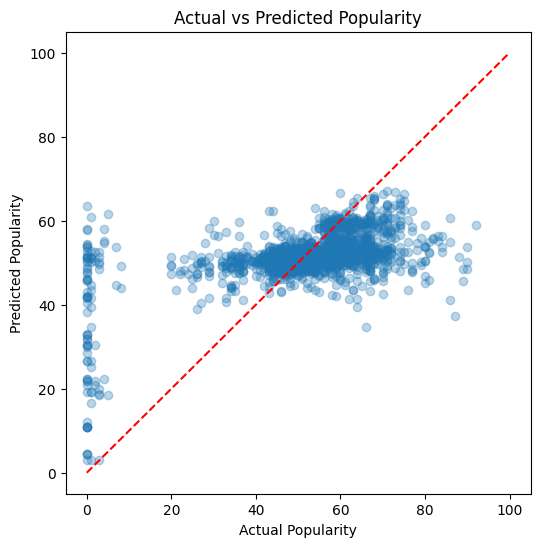

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([0,100],[0,100],'r--')
plt.xlabel("Actual Popularity")
plt.ylabel("Predicted Popularity")
plt.title("Actual vs Predicted Popularity")
plt.show()

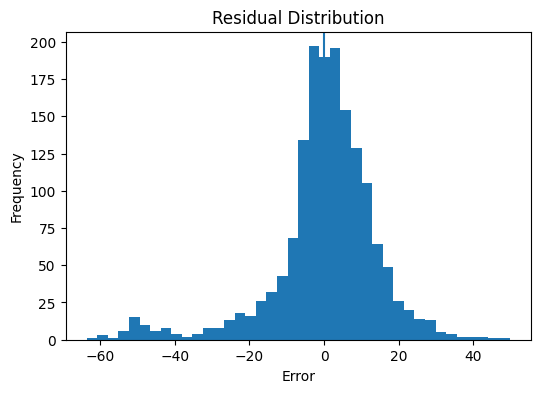

In [11]:
residuals = y_test - y_pred

plt.figure(figsize=(6,4))
plt.hist(residuals, bins=40)
plt.axvline(0)
plt.title("Residual Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

In [12]:
import pandas as pd

feature_importance = pd.Series(
    rf_reg.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Top Features Driving Popularity:")
print(feature_importance.head(10))

Top Features Driving Popularity:
acousticness       0.094283
duration_ms        0.086141
danceability       0.083834
energy             0.079793
valence            0.077389
loudness           0.075434
liveness           0.071614
speechiness        0.071606
tempo              0.070944
track_genre_pop    0.055688
dtype: float64
